<a href="https://colab.research.google.com/github/nelsbuhrley/CSE-450-Machine-learning/blob/main/notebooks/hint_decisiontrees_polars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
# Load some test data
import polars as pl
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import numpy as np

data = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv',schema_overrides={'nr.employed':float})
# Round 'nr.employed' to the nearest whole number and cast to integer
data = data.with_columns(pl.col('nr.employed').round(0).cast(pl.Int64))

print(data.select(pl.col('loan')).unique())
data.sample(10)

shape: (3, 1)
┌─────────┐
│ loan    │
│ ---     │
│ str     │
╞═════════╡
│ unknown │
│ no      │
│ yes     │
└─────────┘


age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
i64,str,str,str,str,str,str,str,str,str,i64,i64,i64,str,f64,f64,f64,f64,i64,str
31,"""entrepreneur""","""married""","""basic.6y""","""no""","""yes""","""no""","""telephone""","""may""","""fri""",3,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
38,"""technician""","""single""","""professional.course""","""no""","""no""","""no""","""cellular""","""sep""","""thu""",4,999,0,"""nonexistent""",-1.1,94.199,-37.5,0.879,4964,"""yes"""
45,"""technician""","""divorced""","""university.degree""","""no""","""yes""","""yes""","""telephone""","""jun""","""thu""",3,999,0,"""nonexistent""",1.4,94.465,-41.8,4.961,5228,"""no"""
76,"""retired""","""married""","""university.degree""","""no""","""no""","""no""","""cellular""","""aug""","""thu""",1,999,1,"""failure""",-1.7,94.027,-38.3,0.899,4992,"""no"""
36,"""technician""","""single""","""unknown""","""no""","""no""","""no""","""cellular""","""jul""","""tue""",1,999,0,"""nonexistent""",1.4,93.918,-42.7,4.962,5228,"""no"""
33,"""blue-collar""","""married""","""basic.9y""","""unknown""","""yes""","""no""","""cellular""","""may""","""fri""",5,999,0,"""nonexistent""",-1.8,92.893,-46.2,1.25,5099,"""yes"""
41,"""services""","""divorced""","""basic.9y""","""no""","""no""","""no""","""telephone""","""jun""","""thu""",1,999,0,"""nonexistent""",1.4,94.465,-41.8,4.958,5228,"""no"""
35,"""blue-collar""","""married""","""basic.6y""","""no""","""yes""","""yes""","""telephone""","""may""","""wed""",3,999,0,"""nonexistent""",1.1,93.994,-36.4,4.856,5191,"""no"""
32,"""admin.""","""married""","""university.degree""","""no""","""yes""","""no""","""cellular""","""may""","""thu""",4,999,1,"""failure""",-1.8,92.893,-46.2,1.327,5099,"""no"""


In [171]:
##lets seperate out some values

features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'campaign', 'pdays', 'previous']

x = data.select(features).to_dummies(features, drop_first=True)
y = data.select(pl.col('y'))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10)

clf = DecisionTreeClassifier(max_depth=4)
clf.fit(x_train, y_train)
clf.score(x_test, y_test)



0.8929053142702994

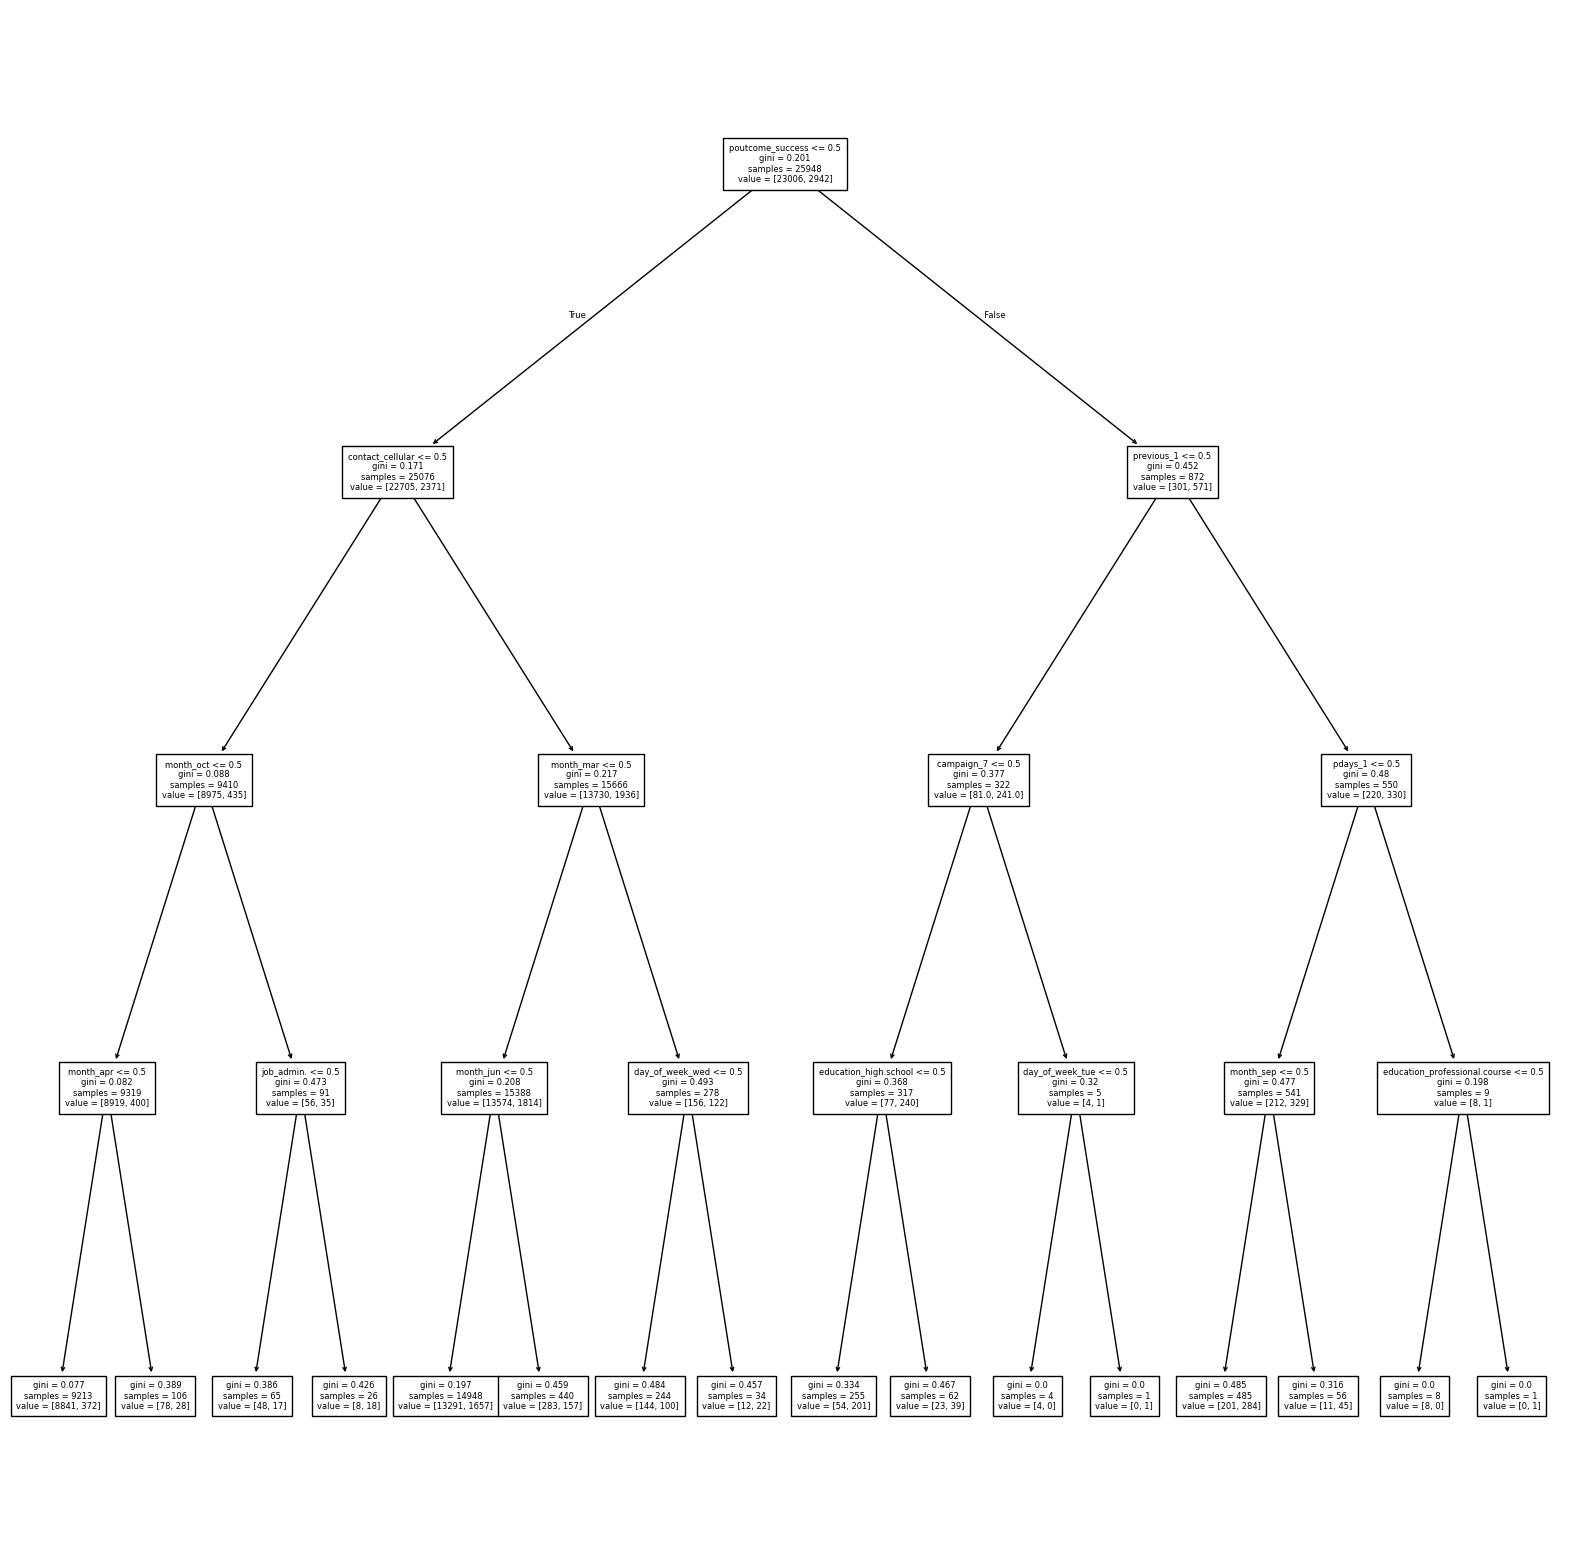

In [155]:
# Let's visualize the tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
tree.plot_tree(clf, fontsize=6, feature_names=x.columns)
plt.show()